<div class="alert alert-info" style="background-color:#001b79; color:white; padding:0px 10px; border-radius:5px;"><h2 style='margin:10px 5px'>K MEAN CLUSTER </h2>
</div>

# Module 9 - Unsupervised Learning 


<div class="alert alert-info" style="background-color:#001b32; color:white; padding:0px 10px; border-radius:5px;"><h2 style='margin:10px 5px'>Problem  Statement </h2>
</div>

## Case Study

Domain –Automotive

focus –Incentivize drivers

## Business challenge/requirement:
    - Lithionpower is the largest provider of electric vehicle(e-vehicle) batteries.  
    It provides battery on a rental model to e-vehicle drivers. 
    Drivers rent battery typically for a day and then replace it with a charged battery from the company. 
    Lithionpower has a variable pricing model based on driver's driving history. 
    As the life of a battery depends on factors such as overspeeding, distance driven per day etc.
    You as a ML expert have  to create a cluster model where drivers can be grouped together based on the driving data.
    
## Key issues:
    Drivers will be incentivized based on the cluster, so grouping has to be accurate 

Considerations:
    NONE

Data volume-4000 records –file driver-data.csv

## Fields in Data
    •id: Unique Id of the driver 
    •mean_dist_day: Mean distance driven by driver per day
    •mean_over_speed_perc: Mean percentage of time a driver was > 5 mph over the speed limit
        
Additional information-NA

## Business benefits
    Increase in profits,up to 15-20% as drivers with poor history will be charged more

## Solution

- By the above statement, looks like company should find out drivers with high speed and more distance covered drivers. These people will use more battery and needs to be charged more

##  1. Import all Librariy

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# data set
driverdata = pd.read_csv(r'..\Dataset\driver-data.csv')
driverdata.head()

,id,mean_dist_day,mean_over_speed_perc
0,3423311935,71.24,28
1,3423313212,52.53,25
2,3423313724,64.54,27
3,3423311373,55.69,22
4,3423310999,54.58,25


## 2. Data Exploration

In [32]:
f1 = driverdata.iloc[:,1].values
f2 = driverdata.iloc[:,2].values
f1
# Combine both data
X =  np.array(list(zip(f1,f2)))
X

array([[ 71.24,  28.  ],
       [ 52.53,  25.  ],
       [ 64.54,  27.  ],
       ...,
       [170.91,  12.  ],
       [176.14,   5.  ],
       [168.03,   9.  ]])

### 2.1 Here Scatter plots will plot for each driver in 2 D space, but not clustered or grouped. In further steps we will do by Kmean clustering

Text(0, 0.5, 'mean_over_speed_perc')

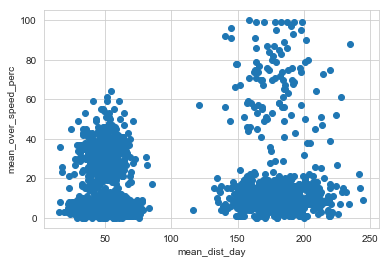

In [33]:
plt.scatter(f1,f2)
plt.xlabel("mean_dist_day")
plt.ylabel("mean_over_speed_perc")

## 3. Building Machine Learning KMean Cluster

### 3.1 Elbow Method to identify K value

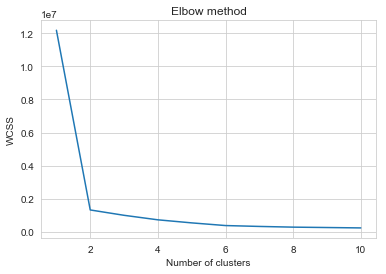

In [34]:
# using elbow method to find the optimal number of clusters
from sklearn.cluster import KMeans

wcss = []  # within cluster square of sums or inertia

for i in range(1,11):
    #n_init:default=10 It is the no. of times the KMeans algorithm will be run with different initial centroid.
    kmeans_model = KMeans(n_clusters=i, init='k-means++',
                         n_init=10, random_state=42)
    #train the model
    kmeans_model.fit(X)
    wcss.append(kmeans_model.inertia_)

plt.plot(range(1,11), wcss)
plt.title("Elbow method")
plt.xlabel("Number of clusters")
plt.ylabel("WCSS")
plt.show()

>  so the appropriate value for k is 2 here. Elbow curve suddenly drops and becomes flat at K=2

### 3.2 Apply Kmean cluster with hardcoded cluster no K=2

In [35]:
kmean = KMeans(n_clusters=2, init='k-means++')
y_means = kmean.fit_predict(X)
y_means  # cluster IDs from 0 to 1
#y_means : cluster numbers which input data belongs to

array([0, 0, 0, ..., 1, 1, 1])

In [36]:
#Centroid
centroid = kmean.cluster_centers_
print(" 2 Centroid of the cluster : \n" , centroid)

 2 Centroid of the cluster : 
 [[ 50.04763437   8.82875   ]
 [180.017075    18.29      ]]


### 3.3 Check the lables of data point
 - Check the size of labels -- should match dataset count 

 - The cluster labels are returned in `kmeans.labels_`. 

In [37]:
print (kmean.labels_)
print (len(kmean.labels_))
print (len(driverdata))

[0 0 0 ... 1 1 1]
4000
4000


## 4. Model Evaluation with Visualization

### 4.1 How many drivers are there in 1st and 2nd Cluster?**?

In [38]:
print (type(kmean.labels_))
unique, counts = np.unique(kmean.labels_, return_counts=True)
print("\n Cluster No: " ,unique)
print("\n Each Cluster counts: " ,counts)
print("\n Drivers in Each Cluster > Cluster no : Cluster people counts: " ,dict(zip(unique, counts)))

<class 'numpy.ndarray'>

 Cluster No:  [0 1]

 Each Cluster counts:  [3200  800]

 Drivers in Each Cluster > Cluster no : Cluster people counts:  {0: 3200, 1: 800}


>  Conclusion: Means 1st cluster has 3200 drivers, 2nd cluster has 800 drivers

### 4.2 Tag labels or cluster no to original dataset

In [39]:
driverdata['cluster'] = kmean.labels_
driverdata.head()

,id,mean_dist_day,mean_over_speed_perc,cluster
0,3423311935,71.24,28,0
1,3423313212,52.53,25,0
2,3423313724,64.54,27,0
3,3423311373,55.69,22,0
4,3423310999,54.58,25,0


### 4.3 Visualize the cluster based on cluster id to give color

####  Method 1: Visualization

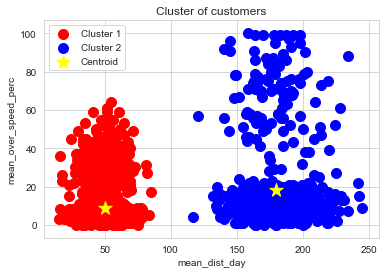

In [40]:
# Method 1
# Here we are displaying 2 clusters

plt.scatter(X[y_means == 0, 0], X[y_means == 0, 1],
           s=100, c='red', label='Cluster 1')
plt.scatter(X[y_means == 1, 0], X[y_means == 1, 1],
           s=100, c='blue', label='Cluster 2')

#Centroid
plt.scatter(centroid[:,0], centroid[:,1],
           s=200, c='yellow', label='Centroid',marker ='*')

plt.title("Cluster of customers")
plt.xlabel("mean_dist_day")
plt.ylabel("mean_over_speed_perc")
plt.legend()
plt.show()

####  Method 2: Visualization

In [41]:
# Method 2

#tHIS is same as X
df_analyze = driverdata.drop('id',axis=1)

#append label_/ predicted o/p to input
df_analyze['cluster'] = kmean.labels_
print(df_analyze.head())


   mean_dist_day  mean_over_speed_perc  cluster
0          71.24                    28        0
1          52.53                    25        0
2          64.54                    27        0
3          55.69                    22        0
4          54.58                    25        0


C:\Users\prabh\Anaconda3\lib\site-packages\seaborn\regression.py:546: UserWarning: The `size` paramter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


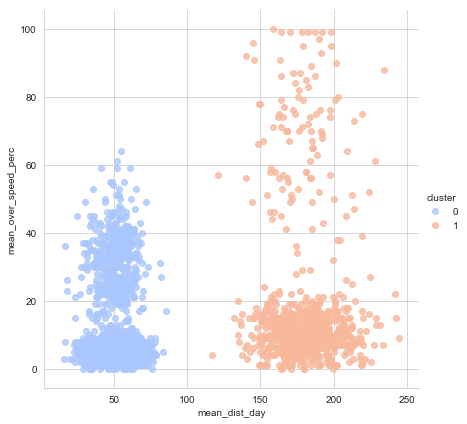

In [42]:
import seaborn as sns

sns.set_style('whitegrid')
sns.lmplot('mean_dist_day','mean_over_speed_perc',data=df_analyze, hue='cluster',
           palette='coolwarm',size=6,aspect=1,fit_reg=False)

## 5. Conclusion

- Cluster 1 -  These are people with minimum "Mean distance per day" and Lesser "mean_over_speed_perc"
        - These are good customer can be charged less

- Cluster 2 -  These are people with max "Mean distance per day" and max and min "mean_over_speed_perc"
        - These are medium usage customer can be charged more


## 6. Kmean cluster with 4 Cluster

### 6.1 Now cluster  the data in 4 groups and answer the same questions as for 2 groups
- Q4. What are the cluster center vectors?
-  Q5. How many drivers are there in each of 4 Cluster?**

In [43]:
kmeans_4 = KMeans(n_clusters=4)
kmeans_4.fit(X)


unique, counts = np.unique(kmeans_4.labels_, return_counts=True)

print("Clusters Centroid : \n" , kmeans_4.cluster_centers_)

print("\n Cluster No: " ,unique)
print("\n Each Cluster counts: " ,counts)
print("\n Drivers in Each Cluster > Cluster no : Cluster people counts: " ,dict(zip(unique, counts)))

Clusters Centroid : 
 [[ 50.40482436  32.36533958]
 [180.34311782  10.52011494]
 [ 49.99263253   5.20447169]
 [177.83509615  70.28846154]]

 Cluster No:  [0 1 2 3]

 Each Cluster counts:  [ 427  696 2773  104]

 Drivers in Each Cluster > Cluster no : Cluster people counts:  {0: 427, 1: 696, 2: 2773, 3: 104}


###  6.2 Plot the Cluster Data 
 
- Q6. What is the inference you can draw from the clustering? **

   mean_dist_day  mean_over_speed_perc  cluster
0          71.24                    28        0
1          52.53                    25        0
2          64.54                    27        0
3          55.69                    22        0
4          54.58                    25        0


C:\Users\prabh\Anaconda3\lib\site-packages\seaborn\regression.py:546: UserWarning: The `size` paramter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


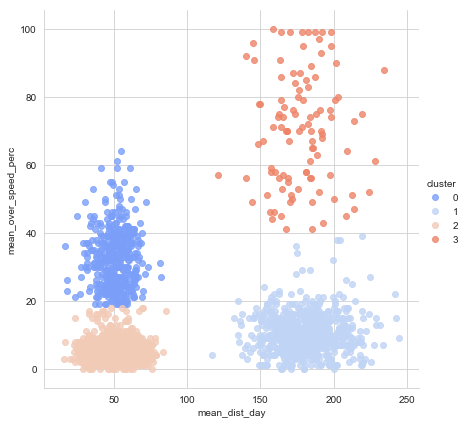

In [44]:
# plot the data 
df_analyze['cluster'] = kmeans_4.labels_
print(df_analyze.head())

sns.set_style('whitegrid')
sns.lmplot('mean_dist_day','mean_over_speed_perc',data=df_analyze, hue='cluster',
           palette='coolwarm',size=6,aspect=1,fit_reg=False)

## 5. Conclusion

- Cluster 0 -  These are people with minimum "Mean distance per day" and Lesser "mean_over_speed_perc"
        - These are good customer can be charged less
    
- Cluster 2 -  These are people with minimum "Mean distance per day" and Higher "mean_over_speed_perc"
        - These are good customer but had little high speed can be charged little more
        
 
- Cluster 3 -  These are people with max "Mean distance per day" and min "mean_over_speed_perc"
        - These are medium usage customer can be charged more
        
     
- Cluster 1 -  These are people with max "Mean distance per day" and max  "mean_over_speed_perc"
        - These are High usage customer can be charged more . These people will use more battery and needs to be charged more
